10000
['Pass' 'Fail' 'Distinction']
1434
8566
0.07842859641766033
0.6734355560826861
                 Feature  Coefficient
0  attendance_percentage     0.398946
1           previous_gpa     0.000000
2    study_hours_per_day     0.023637
3       assignment_score     0.000000
4          midterm_marks    -0.000000


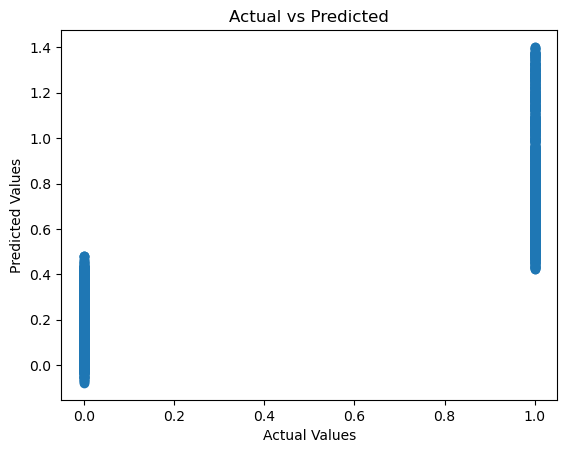

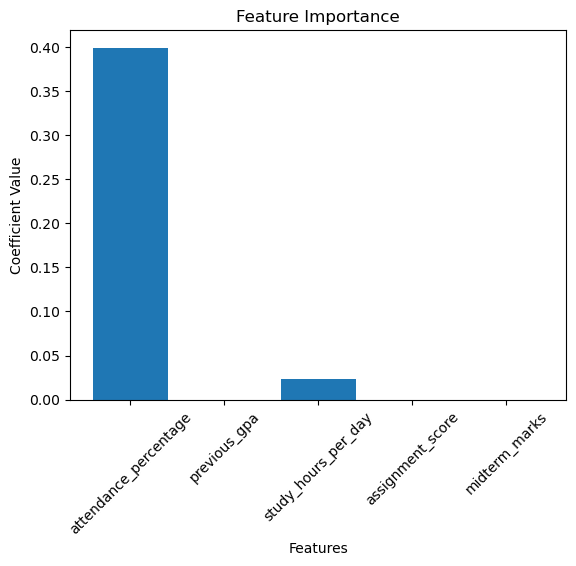

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_excel(r"C:\Users\Divya\OneDrive\Desktop\Dokumen\ML Lab\programs\student_performance (1).xlsx")

print(len(df))
print(df['final_result'].unique())

df['final_result'] = df['final_result'].astype(str).str.strip().str.lower()
df['final_result'] = df['final_result'].map({'pass': 1, 'fail': 0})

print(df['final_result'].isnull().sum())

df = df.dropna(subset=['final_result'])

print(len(df))

X = df[['attendance_percentage',
        'previous_gpa',
        'study_hours_per_day',
        'assignment_score',
        'midterm_marks']]

y = df['final_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mse)
print(r2)

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})

print(coeff_df)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

plt.figure()
plt.bar(X.columns, lasso.coef_)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()